In [6]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE


In [7]:
#LOAD DATASET

df = pd.read_csv("Imperfect_HR_Attrition (1) (1).csv")

print("FIRST 5 ROWS")
pd.set_option('display.max_columns', None)
display(df.head())

print("DATASET SHAPE")
print(df.shape)

print("\nDATASET INFO")
print(df.info())

print("\nNULL VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
display(df.describe())

FIRST 5 ROWS


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,37,No,Travel_Rarely,558,Sales,2.0,3,Marketing,1,656,4.0,Male,75,3,2,Sales Executive,3.0,Married,9602.0,3010,4.0,Y,Yes,11.0,3,3.0,80,1,17.0,3.0,2.0,3,0,1,0.0
1,42,No,Travel_Rarely,265,Sales,5.0,2,Marketing,1,1029,4.0,Male,90,3,5,Manager,3.0,Married,18303.0,7770,6.0,Y,No,13.0,3,2.0,80,0,21.0,3.0,4.0,1,0,0,0.0
2,19,Yes,Travel_Frequently,602,Sales,1.0,1,Technical Degree,1,235,3.0,Female,100,1,1,Sales Representative,1.0,Single,2325.0,20989,0.0,Y,No,21.0,4,1.0,80,0,1.0,5.0,4.0,0,0,0,0.0
3,40,Yes,Travel_Rarely,1329,Research & Development,7.0,3,Life Sciences,1,1649,1.0,Male,73,3,1,Laboratory Technician,1.0,Single,2166.0,3339,3.0,Y,Yes,14.0,3,2.0,80,0,10.0,3.0,1.0,4,2,0,3.0
4,26,No,Travel_Rarely,1167,Sales,5.0,3,Other,1,2060,4.0,Female,30,2,1,Sales Representative,3.0,Single,2966.0,21378,0.0,Y,No,0.0,3,4.0,80,0,5.0,2.0,3.0,4,2,0,0.0


DATASET SHAPE
(1749, 35)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1749 entries, 0 to 1748
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1749 non-null   int64  
 1   Attrition                 1749 non-null   object 
 2   BusinessTravel            1749 non-null   object 
 3   DailyRate                 1749 non-null   int64  
 4   Department                1749 non-null   object 
 5   DistanceFromHome          1640 non-null   float64
 6   Education                 1749 non-null   int64  
 7   EducationField            1749 non-null   object 
 8   EmployeeCount             1749 non-null   int64  
 9   EmployeeNumber            1749 non-null   int64  
 10  EnvironmentSatisfaction   1614 non-null   float64
 11  Gender                    1680 non-null   object 
 12  HourlyRate                1749 non-null   int64  
 13  JobInvolvement          

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1749.000000,1749.000000,1640.000000,1749.000000,1749.0,1749.000000,1614.000000,1749.000000,1749.000000,1749.000000,1608.000000,1728.000000,1749.000000,1592.000000,1660.000000,1749.000000,1607.000000,1749.0,1749.000000,1748.000000,1622.000000,1619.000000,1749.000000,1749.000000,1749.00000,1666.000000
mean,36.390509,802.419097,9.488415,2.899943,1.0,1035.115495,2.679058,65.792453,2.686678,2.003431,2.695274,6442.207755,14244.236135,2.760050,15.165060,3.159520,2.662103,80.0,0.763293,10.818650,2.771270,2.735639,6.762722,4.029160,2.18582,3.990396
std,9.278006,404.683953,8.233912,1.017999,0.0,598.999189,1.108428,20.368960,0.734995,1.095544,1.113554,5531.862108,7140.406050,2.560683,3.952458,0.366265,1.094968,0.0,0.873590,7.788398,1.268452,0.719177,6.125991,3.589929,3.20831,3.544809
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,0.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,29.000000,459.000000,2.000000,2.000000,1.0,502.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2800.000000,8040.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,2.000000,2.000000,0.00000,2.000000
50%,35.000000,798.000000,7.000000,3.000000,1.0,1043.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4776.000000,14255.000000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,9.000000,3.000000,3.000000,5.000000,3.000000,1.00000,3.000000
75%,42.000000,1162.000000,15.000000,4.000000,1.0,1554.000000,4.000000,84.000000,3.000000,3.000000,4.000000,7995.250000,20489.000000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,14.000000,3.000000,3.000000,9.000000,7.000000,3.00000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,99800.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.00000,17.000000


In [8]:
#HANDLE NULL VALUES & REMOVE DUPLICATES

# Remove duplicate rows
print("DUPLICATE ROWS BEFORE DROPPING:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nDUPLICATE ROWS AFTER DROPPING:")
print(df.duplicated().sum())


print("\nNULL VALUES BEFORE IMPUTATION:")
print(df.isnull().sum())


numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns


if len(numeric_cols) > 0:
    numeric_imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])


if len(categorical_cols) > 0:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

print("\nNULL VALUES AFTER IMPUTATION:")
print(df.isnull().sum())

print("\nDATASET SHAPE AFTER CLEANING:", df.shape)

DUPLICATE ROWS BEFORE DROPPING:
97

DUPLICATE ROWS AFTER DROPPING:
0

NULL VALUES BEFORE IMPUTATION:
Age                           0
Attrition                     0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome            109
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction     133
Gender                       69
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction             141
MaritalStatus                 0
MonthlyIncome                20
MonthlyRate                   0
NumCompaniesWorked          157
Over18                        0
OverTime                      0
PercentSalaryHike            88
PerformanceRating             0
RelationshipSatisfaction    141
StandardHours                 0
StockOptionLevel              0
Tot

C:\Users\ircpr\AppData\Local\Temp\ipykernel_13824\2491968602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df_eda, palette=['#4CAF50', '#F44336'], edgecolor='black')


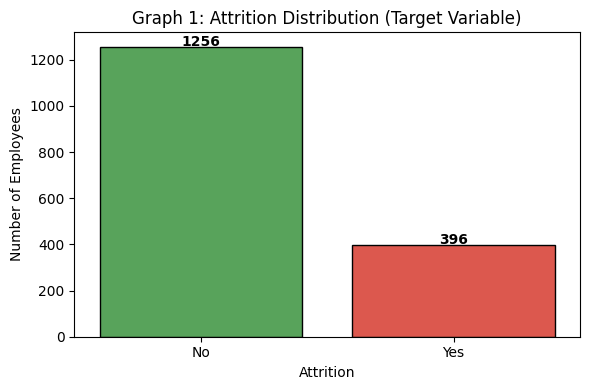

Inference: The dataset is imbalanced — most employees did NOT leave (No). This explains why SMOTE is applied later to balance classes.


In [9]:
df_eda = df.copy()

# ---- Target Variable Distribution ----
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Attrition', data=df_eda, palette=['#4CAF50', '#F44336'], edgecolor='black')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height() + 5), ha='center', fontweight='bold')
plt.title('Graph 1: Attrition Distribution (Target Variable)')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()
print("Inference: The dataset is imbalanced — most employees did NOT leave (No). This explains why SMOTE is applied later to balance classes.")


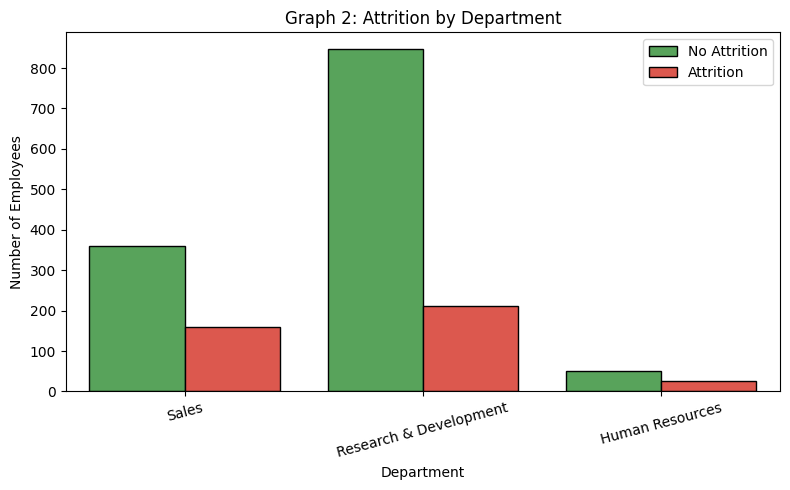

Inference: Sales department shows the highest attrition count. HR and R&D also have attrition but relatively lower. This highlights Sales as a high-risk department.


In [10]:
# ---- Attrition by Department ----
plt.figure(figsize=(8, 5))
sns.countplot(x='Department', hue='Attrition', data=df_eda, palette=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Graph 2: Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=15)
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.show()
print("Inference: Sales department shows the highest attrition count. HR and R&D also have attrition but relatively lower. This highlights Sales as a high-risk department.")


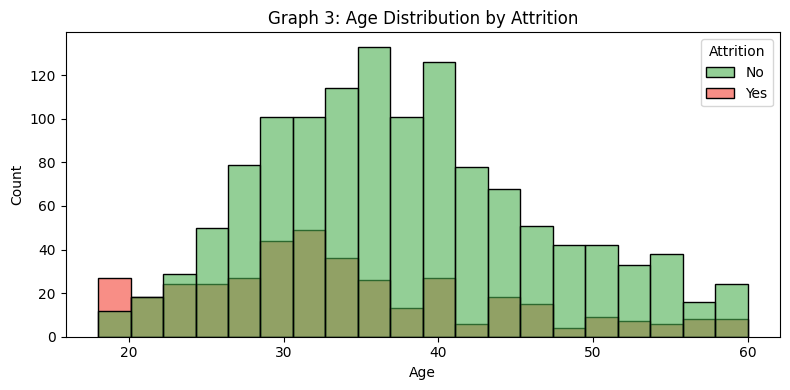

Inference: Younger employees (20–35 age range) tend to leave more. Older employees are more stable. Companies should focus retention efforts on younger staff.


In [11]:
# ---- Age Distribution by Attrition ----
plt.figure(figsize=(8, 4))
sns.histplot(data=df_eda, x='Age', hue='Attrition', bins=20, palette=['#4CAF50', '#F44336'], alpha=0.6, edgecolor='black')
plt.title('Graph 3: Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Inference: Younger employees (20–35 age range) tend to leave more. Older employees are more stable. Companies should focus retention efforts on younger staff.")


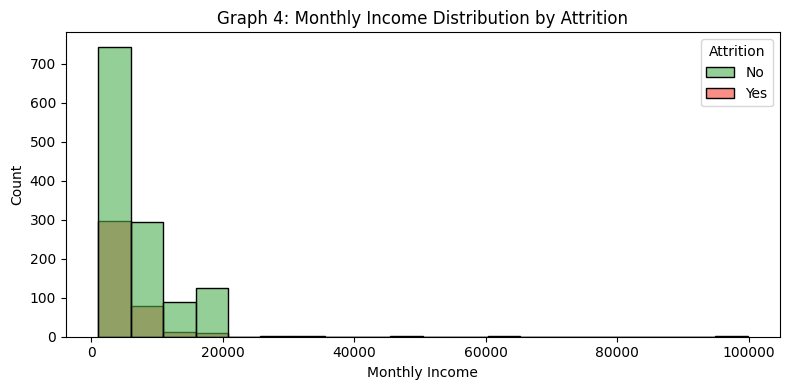

Inference: Employees with lower monthly income are more likely to leave. Higher salaries are associated with employee retention.


In [12]:
# ---- Monthly Income Distribution by Attrition ----
plt.figure(figsize=(8, 4))
sns.histplot(data=df_eda, x='MonthlyIncome', hue='Attrition', bins=20, palette=['#4CAF50', '#F44336'], alpha=0.6, edgecolor='black')
plt.title('Graph 4: Monthly Income Distribution by Attrition')
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Inference: Employees with lower monthly income are more likely to leave. Higher salaries are associated with employee retention.")


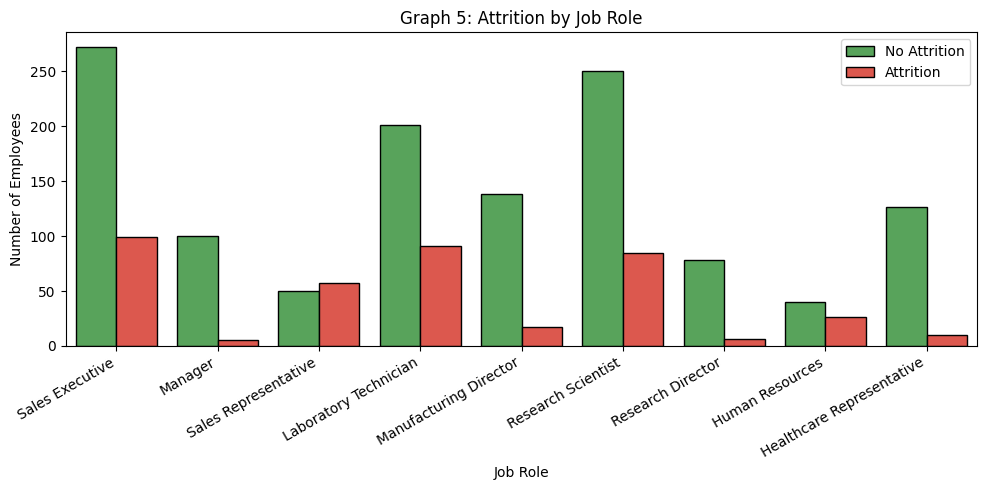

Inference: Sales Executives and Laboratory Technicians have the highest attrition. Managers and Research Directors are more stable roles.


In [13]:
# ---- Attrition by Job Role ----
plt.figure(figsize=(10, 5))
sns.countplot(x='JobRole', hue='Attrition', data=df_eda, palette=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Graph 5: Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.xticks(rotation=30, ha='right')
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.show()
print("Inference: Sales Executives and Laboratory Technicians have the highest attrition. Managers and Research Directors are more stable roles.")


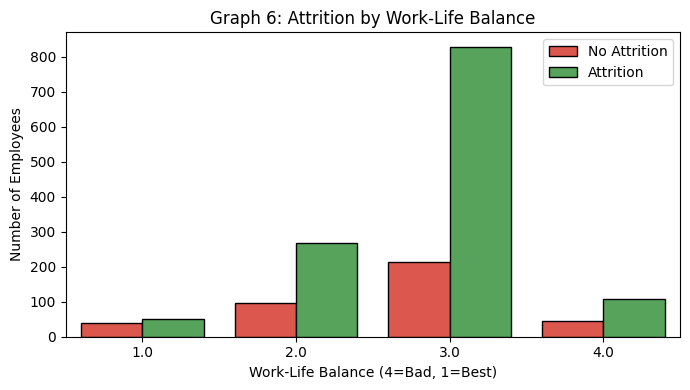

Inference: Employees with a Work-Life Balance score of 1 (Bad) have a noticeably higher attrition rate. Better work-life balance leads to greater retention.


In [14]:
# ---- Attrition by Work-Life Balance ----
plt.figure(figsize=(7, 4))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df_eda, palette=['#F44336','#4CAF50' ], edgecolor='black')
plt.title('Graph 6: Attrition by Work-Life Balance')
plt.xlabel('Work-Life Balance (4=Bad, 1=Best)')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.show()
print("Inference: Employees with a Work-Life Balance score of 1 (Bad) have a noticeably higher attrition rate. Better work-life balance leads to greater retention.")


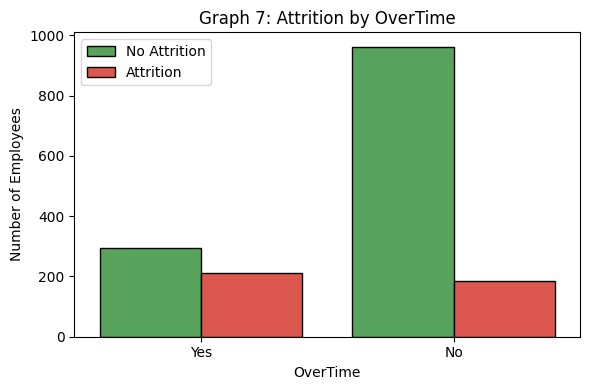

Inference: Employees who work overtime have a significantly higher attrition rate. Overtime is a strong indicator of burnout and quitting.


In [15]:
# ---- Attrition by OverTime ----
plt.figure(figsize=(6, 4))
sns.countplot(x='OverTime', hue='Attrition', data=df_eda, palette=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Graph 7: Attrition by OverTime')
plt.xlabel('OverTime')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.show()
print("Inference: Employees who work overtime have a significantly higher attrition rate. Overtime is a strong indicator of burnout and quitting.")


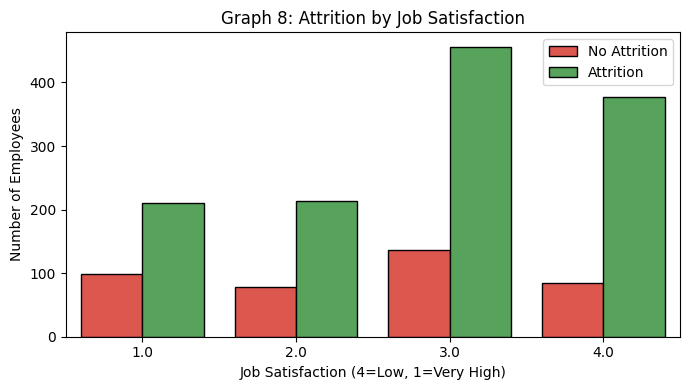

Inference: Lower job satisfaction levels (4 and 3) correspond to higher attrition. Improving job satisfaction can directly reduce employee turnover.


In [16]:
# ---- Attrition by Job Satisfaction ----
plt.figure(figsize=(7, 4))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df_eda, palette=[ '#F44336','#4CAF50'], edgecolor='black')
plt.title('Graph 8: Attrition by Job Satisfaction')
plt.xlabel('Job Satisfaction (4=Low, 1=Very High)')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.show()
print("Inference: Lower job satisfaction levels (4 and 3) correspond to higher attrition. Improving job satisfaction can directly reduce employee turnover.")


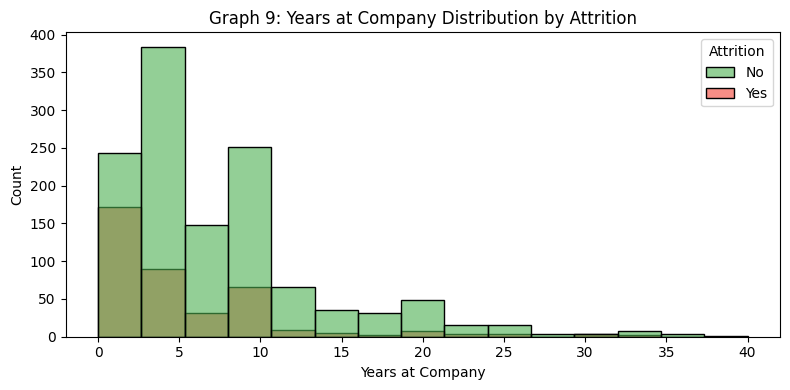

Inference: Employees who have been with the company for fewer years (0–5 years) are more likely to leave. The first few years are critical for retention.


In [17]:
# ---- Years at Company Distribution by Attrition ----
plt.figure(figsize=(8, 4))
sns.histplot(data=df_eda, x='YearsAtCompany', hue='Attrition', bins=15, palette=['#4CAF50', '#F44336'], alpha=0.6, edgecolor='black')
plt.title('Graph 9: Years at Company Distribution by Attrition')
plt.xlabel('Years at Company')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Inference: Employees who have been with the company for fewer years (0–5 years) are more likely to leave. The first few years are critical for retention.")



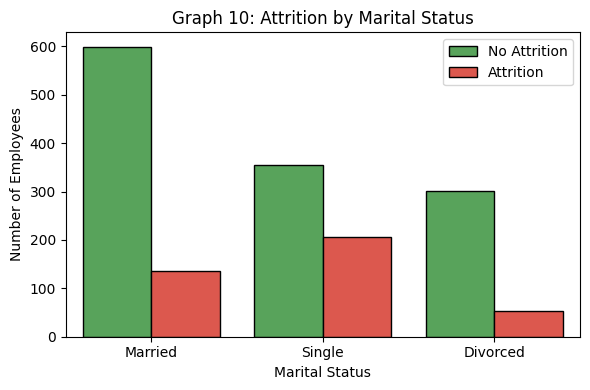

Inference: Single employees have a higher attrition rate compared to married or divorced ones. This may be due to greater flexibility to change jobs without family commitments.


In [18]:
# ----Attrition by Marital Status ----
plt.figure(figsize=(6, 4))
sns.countplot(x='MaritalStatus', hue='Attrition', data=df_eda, palette=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Graph 10: Attrition by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.show()
print("Inference: Single employees have a higher attrition rate compared to married or divorced ones. This may be due to greater flexibility to change jobs without family commitments.")

In [19]:
#LABEL ENCODING

label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    label_encoders[col] = le

print("LABEL ENCODING COMPLETED")

LABEL ENCODING COMPLETED


In [20]:
#DROP CONSTANT & ID COLUMNS
drop_columns = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours',
    'Education',
]

df.drop(columns=drop_columns, inplace=True)

print("Columns dropped successfully")

print("\nCurrent Shape :", df.shape)

Columns dropped successfully

Current Shape : (1652, 30)


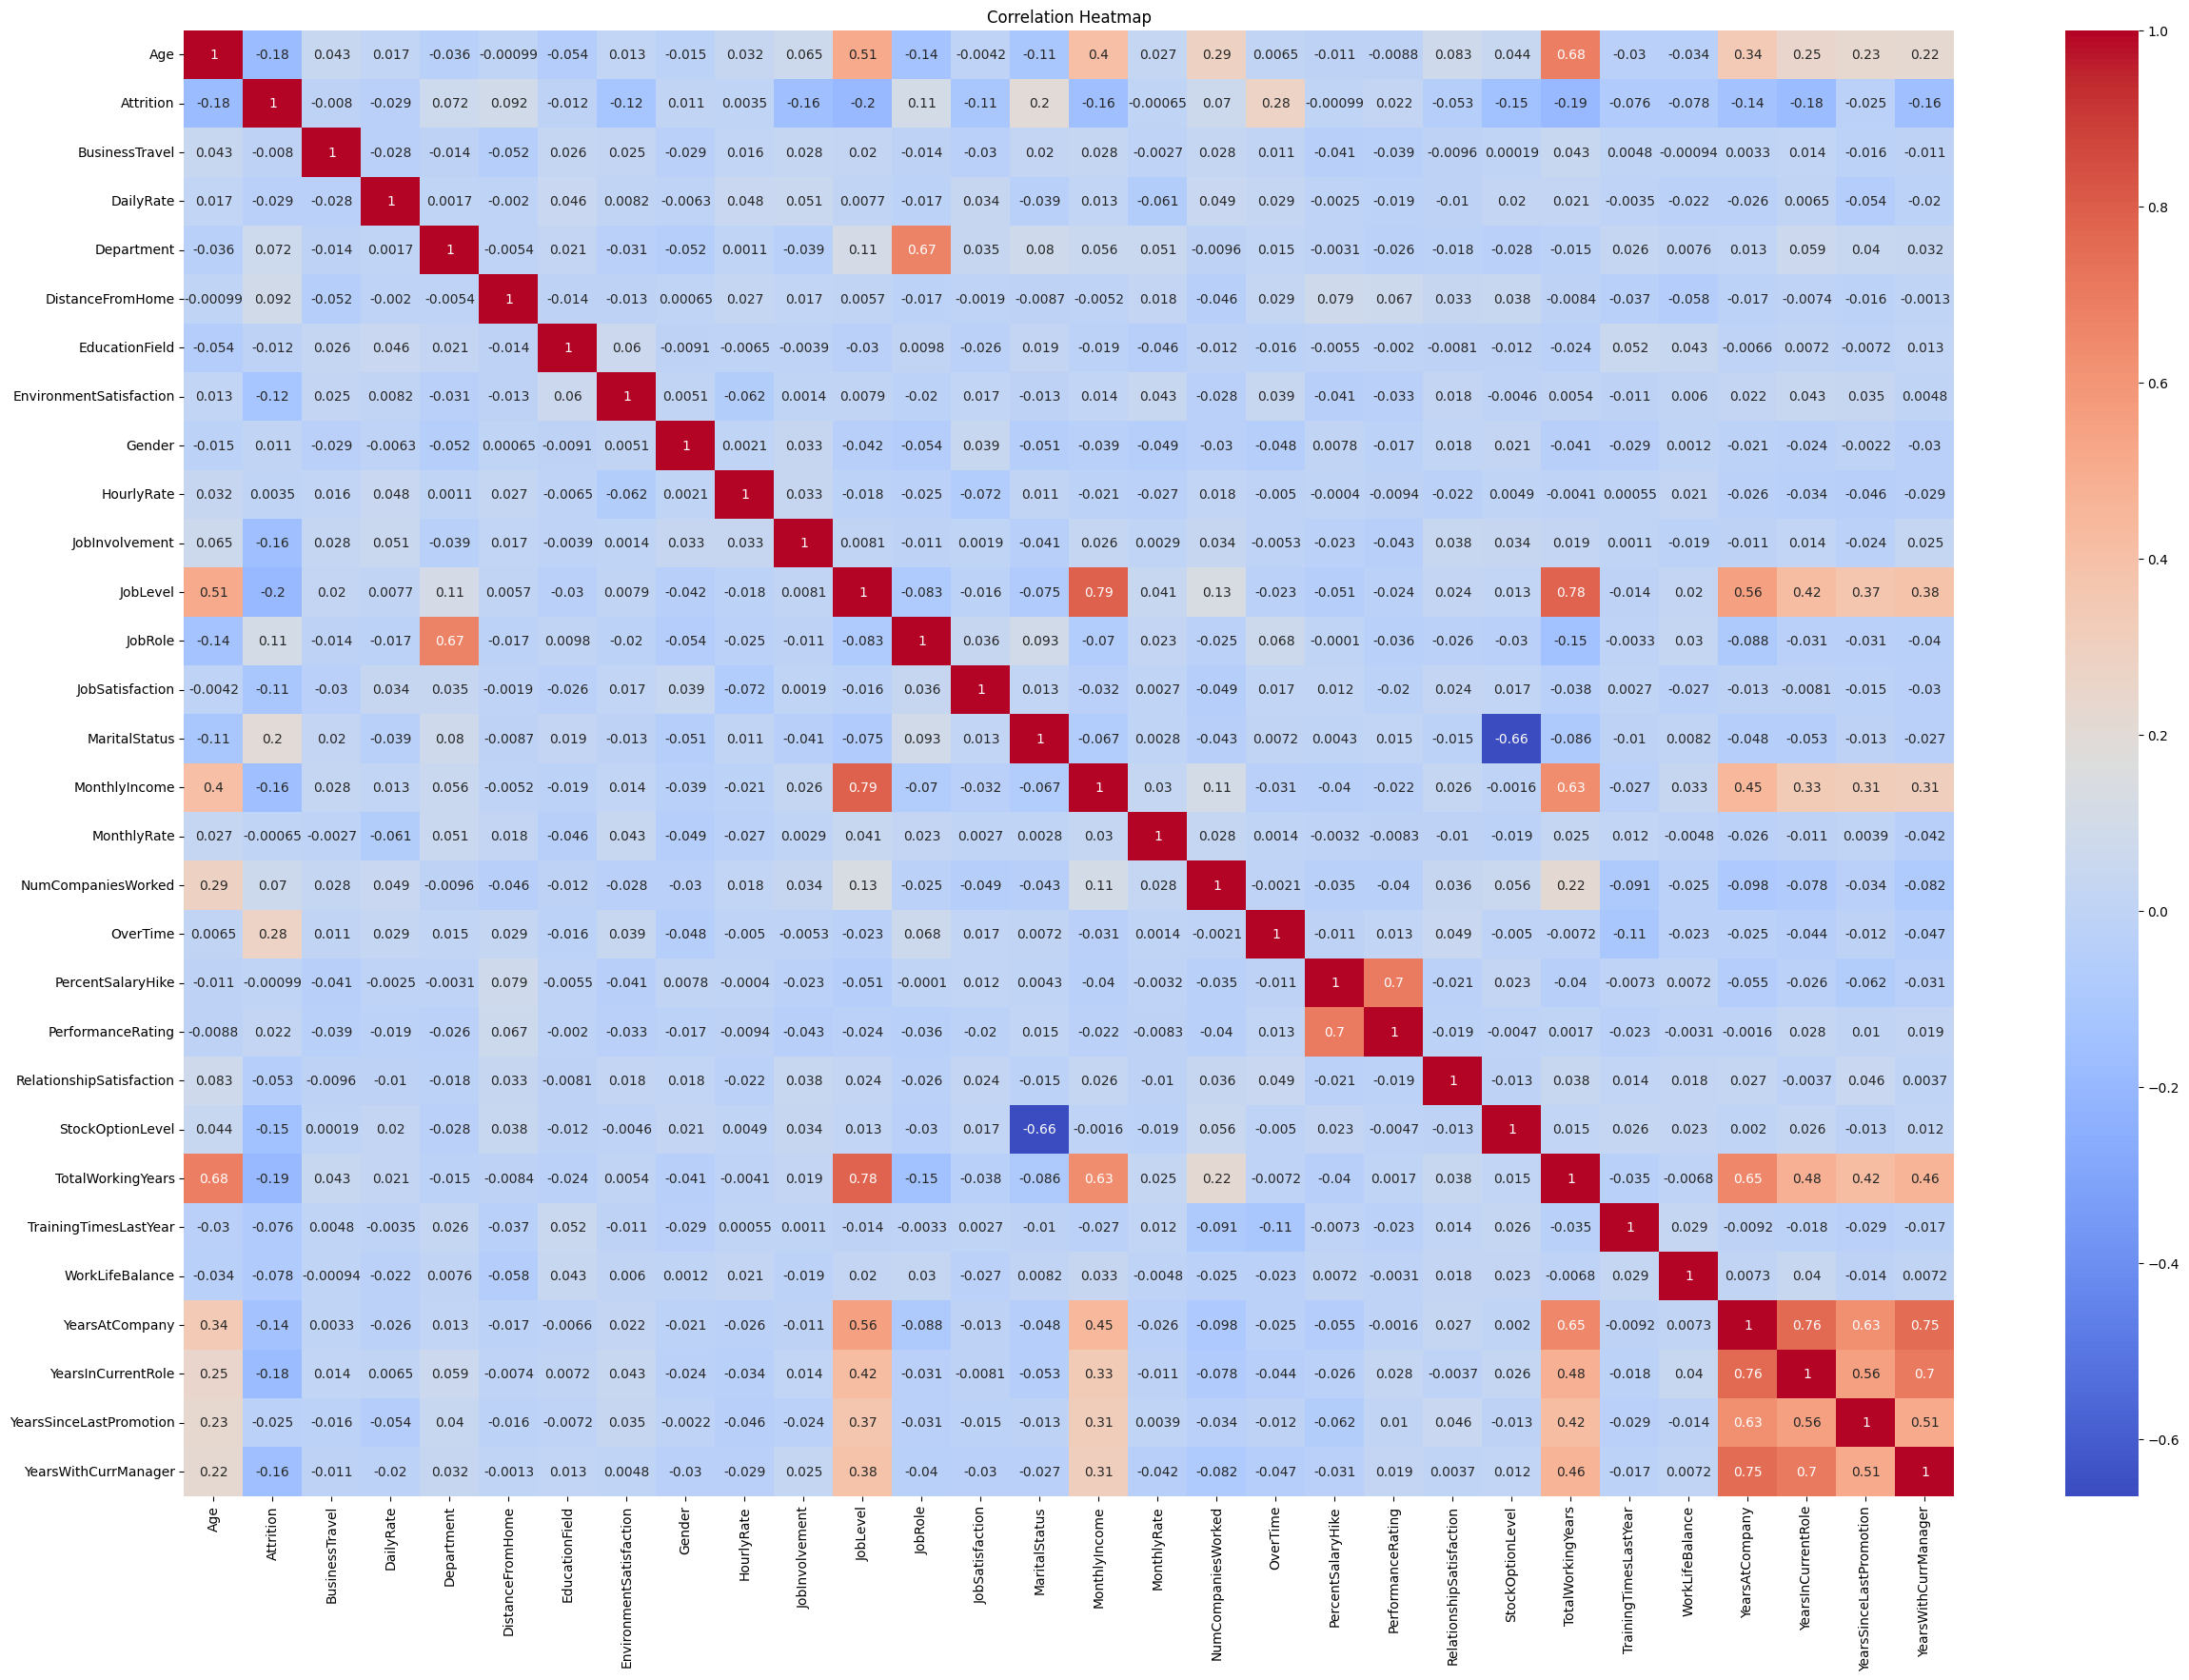

In [21]:
#HEATMAP
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [22]:
#FEATURE SELECTION & TRAIN TEST SPLIT
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("X SHAPE :", X.shape)
print("Y SHAPE :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X SHAPE : (1652, 29)
Y SHAPE : (1652,)


In [23]:
#EVALUATION FUNCTION
results = []
def evaluate_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    
    results.append([name,accuracy,precision,recall,f1,roc])
    print(f"\n{name} RESULTS")
    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1 Score :", f1)
    print("ROC AUC :", roc)
    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test, y_pred))
    


In [24]:
#LOGISTIC REGRESSION
lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model("Logistic Regression", y_test, y_pred_lr)



Logistic Regression RESULTS
Accuracy : 0.8157099697885196
Precision : 0.75
Recall : 0.5567010309278351
F1 Score : 0.6390532544378699
ROC AUC : 0.7398889770023791

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.92      0.88       234
           1       0.75      0.56      0.64        97

    accuracy                           0.82       331
   macro avg       0.79      0.74      0.76       331
weighted avg       0.81      0.82      0.81       331



In [25]:
#RANDOM FOREST
rf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf)



Random Forest RESULTS
Accuracy : 0.9244712990936556
Precision : 0.95
Recall : 0.7835051546391752
F1 Score : 0.8587570621468926
ROC AUC : 0.8832055687725789

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       234
           1       0.95      0.78      0.86        97

    accuracy                           0.92       331
   macro avg       0.93      0.88      0.90       331
weighted avg       0.93      0.92      0.92       331



In [26]:
# DECISION TREE
dt = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42))
])
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
evaluate_model("Decision Tree", y_test, y_pred_dt)



Decision Tree RESULTS
Accuracy : 0.7673716012084593
Precision : 0.6515151515151515
Recall : 0.44329896907216493
F1 Score : 0.5276073619631901
ROC AUC : 0.6725041853907834

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       234
           1       0.65      0.44      0.53        97

    accuracy                           0.77       331
   macro avg       0.72      0.67      0.69       331
weighted avg       0.75      0.77      0.75       331



In [27]:
#KNN
knn = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
evaluate_model("KNN", y_test, y_pred_knn)



KNN RESULTS
Accuracy : 0.7583081570996979
Precision : 0.639344262295082
Recall : 0.4020618556701031
F1 Score : 0.4936708860759494
ROC AUC : 0.6540223808265045

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       234
           1       0.64      0.40      0.49        97

    accuracy                           0.76       331
   macro avg       0.71      0.65      0.67       331
weighted avg       0.74      0.76      0.74       331



In [28]:
#XGBOOST
xgb_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
evaluate_model("XGBoost", y_test, y_pred_xgb)



XGBoost RESULTS
Accuracy : 0.918429003021148
Precision : 0.8723404255319149
Recall : 0.845360824742268
F1 Score : 0.8586387434554974
ROC AUC : 0.8970393867301084

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       234
           1       0.87      0.85      0.86        97

    accuracy                           0.92       331
   macro avg       0.90      0.90      0.90       331
weighted avg       0.92      0.92      0.92       331



d:\Python 3.11\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:33:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [29]:
#SVM
svm = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=42))
])
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
evaluate_model("SVM", y_test, y_pred_svm)



SVM RESULTS
Accuracy : 0.8580060422960725
Precision : 0.8787878787878788
Recall : 0.5979381443298969
F1 Score : 0.7116564417177914
ROC AUC : 0.7818750550709314

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       234
           1       0.88      0.60      0.71        97

    accuracy                           0.86       331
   macro avg       0.87      0.78      0.81       331
weighted avg       0.86      0.86      0.85       331



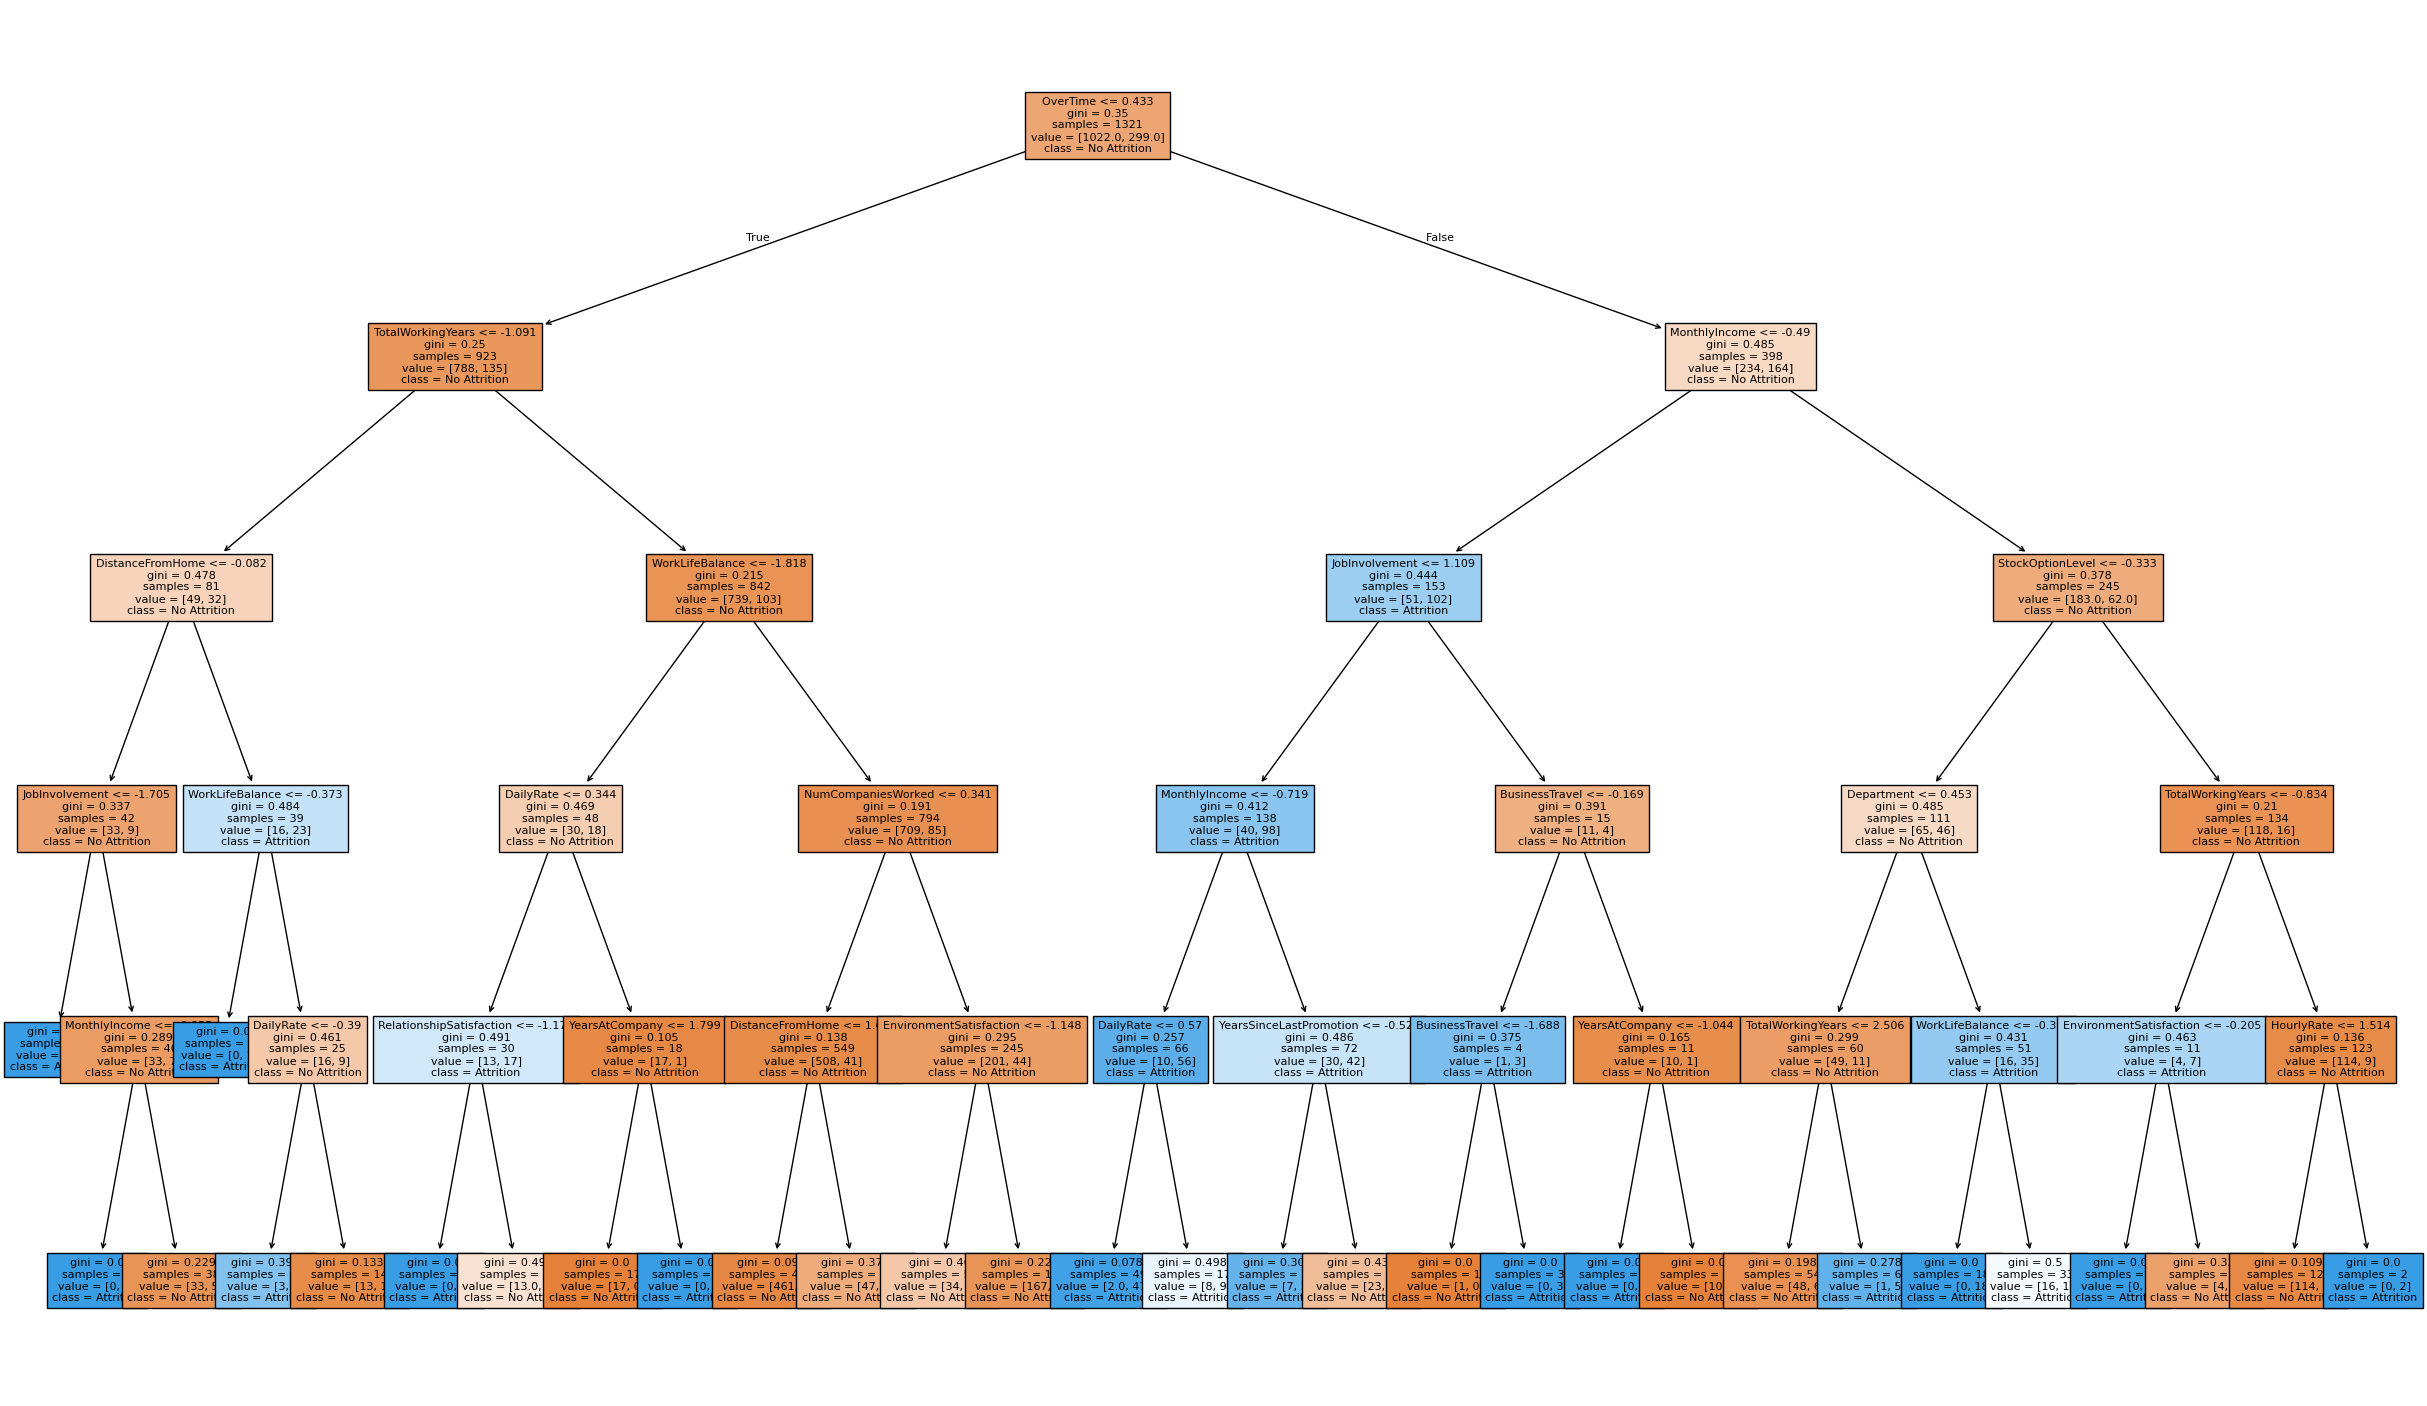

In [30]:
# DECISION TREE PLOT
plt.figure(figsize=(31, 18))
plot_tree(dt.named_steps['model'], feature_names=X.columns, class_names=['No Attrition', 'Attrition'], filled=True, fontsize=8)
plt.show()


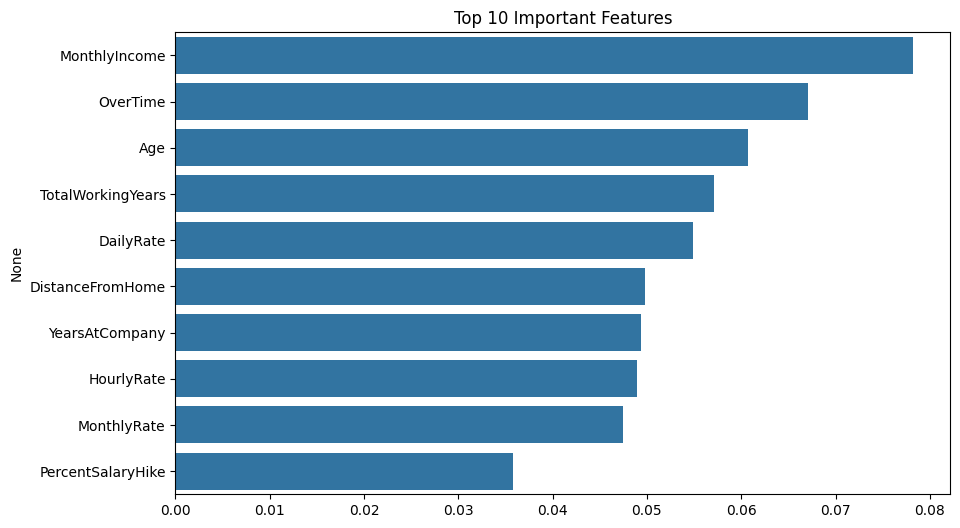

In [31]:
#RANDOM FOREST FEATURE IMPORTANCE
importance = pd.Series(rf.named_steps['model'].feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values[:10], y=importance.index[:10])
plt.title("Top 10 Important Features")
plt.show()


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.815710,0.750000,0.556701,0.639053,0.739889
1,Random Forest,0.924471,0.950000,0.783505,0.858757,0.883206
2,Decision Tree,0.767372,0.651515,0.443299,0.527607,0.672504
3,KNN,0.758308,0.639344,0.402062,0.493671,0.654022
4,XGBoost,0.918429,0.872340,0.845361,0.858639,0.897039
5,SVM,0.858006,0.878788,0.597938,0.711656,0.781875


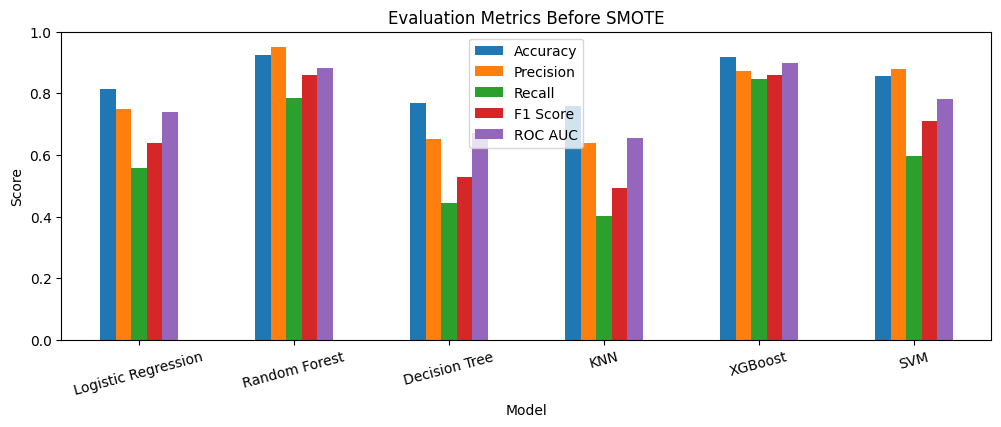

In [32]:
#COMPARISON TABLE
results_df = pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC'])
display(results_df)

#METRICS GRAPH
metrics_df = results_df.set_index("Model")
metrics_df.plot(kind='bar',figsize=(12,4))
plt.title("Evaluation Metrics Before SMOTE")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend()
plt.show()

In [33]:
#APPLY SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("Before SMOTE")
print(y_train.value_counts())
print("\nAfter SMOTE")
print(pd.Series(y_smote).value_counts())


Before SMOTE
Attrition
0    1022
1     299
Name: count, dtype: int64

After SMOTE
Attrition
0    1022
1    1022
Name: count, dtype: int64


In [34]:
#TRAIN MODELS AFTER SMOTE
smote_results = []
def evaluate_smote_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    smote_results.append([name, accuracy, precision, recall, f1, roc])

# Logistic Regression + SMOTE
lr_smote = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
lr_smote.fit(X_smote, y_smote)
y_pred_lr_smote = lr_smote.predict(X_test)
evaluate_smote_model("LR + SMOTE", y_test, y_pred_lr_smote)

# Random Forest + SMOTE
rf_smote = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_smote.fit(X_smote, y_smote)
y_pred_rf_smote = rf_smote.predict(X_test)
evaluate_smote_model("RF + SMOTE", y_test, y_pred_rf_smote)

# Decision Tree + SMOTE
dt_smote = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42))
])
dt_smote.fit(X_smote, y_smote)
y_pred_dt_smote = dt_smote.predict(X_test)
evaluate_smote_model("DT + SMOTE", y_test, y_pred_dt_smote)

# KNN + SMOTE
knn_smote = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
knn_smote.fit(X_smote, y_smote)
y_pred_knn_smote = knn_smote.predict(X_test)
evaluate_smote_model("KNN + SMOTE", y_test, y_pred_knn_smote)

# XGBoost + SMOTE
xgb_smote = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_smote.fit(X_smote, y_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test)
evaluate_smote_model("XGBoost + SMOTE", y_test, y_pred_xgb_smote)

# SVM + SMOTE
svm_smote = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=42))
])
svm_smote.fit(X_smote, y_smote)
y_pred_svm_smote = svm_smote.predict(X_test)
evaluate_smote_model("SVM + SMOTE", y_test, y_pred_svm_smote)


d:\Python 3.11\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:34:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LR + SMOTE,0.749245,0.550000,0.793814,0.649789,0.762292
1,RF + SMOTE,0.933535,0.931034,0.835052,0.880435,0.904705
2,DT + SMOTE,0.725076,0.525862,0.628866,0.572770,0.696912
3,KNN + SMOTE,0.731118,0.523810,0.907216,0.664151,0.782668
4,XGBoost + SMOTE,0.915408,0.879121,0.824742,0.851064,0.888867
5,SVM + SMOTE,0.854985,0.742574,0.773196,0.757576,0.831042


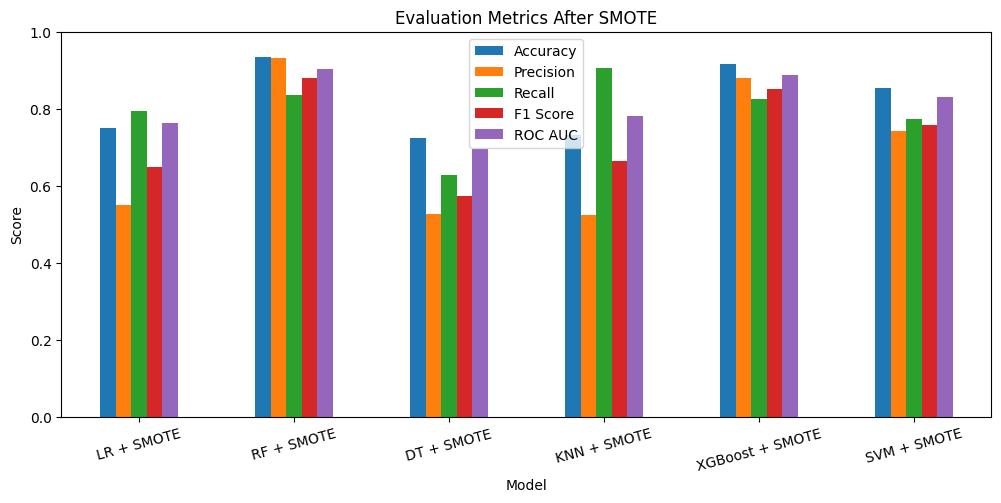

In [35]:
#SMOTE COMPARISON TABLE
smote_results_df = pd.DataFrame(smote_results,columns=['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC'])
display(smote_results_df)

#AFTER SMOTE METRICS GRAPH
smote_metrics_df = smote_results_df.set_index("Model")
smote_metrics_df.plot(kind='bar',figsize=(12,5))
plt.title("Evaluation Metrics After SMOTE")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend()
plt.show()

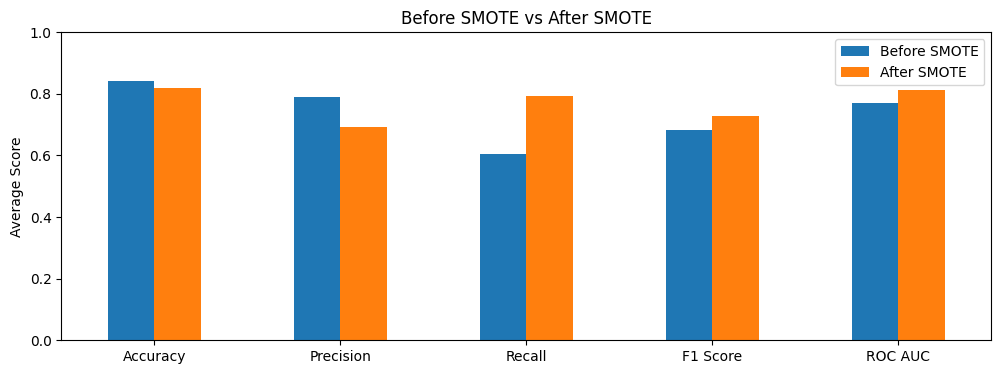

In [36]:
#BEFORE VS AFTER SMOTE COMPARISON
before_smote_avg = results_df.drop("Model", axis=1).mean()
after_smote_avg = smote_results_df.drop("Model", axis=1).mean()
comparison_df = pd.DataFrame({"Before SMOTE": before_smote_avg,"After SMOTE": after_smote_avg})
comparison_df.plot(kind='bar',figsize=(12,4))
plt.title("Before SMOTE vs After SMOTE")
plt.ylabel("Average Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend()
plt.show()